# Inference for U-Net architecture
Modèles basés sur l'architeture U-Net :
- U-Net avec encodeur ResNet34
- ResAttentionUNetPlusPlus
- Attention Gated Multi ResU-Net

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from matplotlib import pyplot as plt
import segmentation_models_pytorch as smp
from pathlib import Path
import sys
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from matplotlib.colors import LinearSegmentedColormap

import pickle 

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

# Importation des fonctions utilitaires
from utils.models_config import collate_fn_sequence, collate_fn, split_dataset, dataset_to_dict, get_metrics
from utils.stats_fct import overlay_mask, mask_to_yolo_polygons
from utils.post_traitement import keep_largest_components, fill_holes

# Importation des architectures de modèles
from models.ResAttentionUNetPlusPlus import ResAttentionUNetPlusPlus
from models.AttentionMultiResUNet import AttentionMultiResUNet
from models.CSANet import CSANet
from models.xLSTMUNet import xLSTMUNet

/home/ldepiero/Debut/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import random

# Seed global pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Déterminisme complet des opérations cuDNN (au prix d'un léger ralentissement)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Importation et traitement des données

In [3]:
# -------- 1. Importation des données --------
all_images_dir = "../data/COCO/images"  # Images

# -------- 0. Sélection de la variante (pilote annotations + poids + architecture) --------
MODEL_VARIANT = "3_classes"  # "2_classes" ou "3_classes" ou "csanet" ou "xlstm"

VARIANT_CONFIGS = {
    "2_classes": {
        "annotations_json": "../data/COCO/annotations_2_classes.json",
        "weights_pattern": "saves/unet_finetuned_fold_{fold}_res34_2.pth",
        "dim": "2",
        "arch": "unet_resnet34",
    },
    "3_classes": {
        "annotations_json": "../data/COCO/annotations.json",
        "weights_pattern": "saves/unet_finetuned_fold_{fold}_unet_test.pth", #"unet_finetuned_fold_{fold}_res34.pth"
        "dim": "2",
        "arch": "unet_resnet34",
    },
    "csanet": {
        "annotations_json": "../data/COCO/annotations.json",
        "weights_pattern": "saves/unet_finetuned_fold_{fold}_csanet.pth",
        "dim": "2.5D",
        "arch": "csanet",
    },
    "xlstm": {
        "annotations_json": "../data/COCO/annotations.json",
        "weights_pattern": "saves/unet_finetuned_fold_{fold}_xLSTM.pth",
        "dim": "2.5D",
        "arch": "xlstm",
    },


}

variant_config = VARIANT_CONFIGS[MODEL_VARIANT]
annotations_json = variant_config["annotations_json"]
weights_pattern = variant_config["weights_pattern"]
IS_SEQUENCE = variant_config["dim"] == "2.5D"  # True pour les modèles 2,5D séquentiels (csanet / xlstm)
results_dir = f"results/{MODEL_VARIANT}"
masks_dir = f"masks/{MODEL_VARIANT}"

# Importation du Data Frame avec les metadata
df = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# ignore_category_id : id COCO de la catégorie "ignore" si elle existe dans l'export (None sinon).
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(df, annotations_json, all_images_dir)

# Canal du masque sur lequel appliquer la zone "ignore" (uniquement la classe Gonade)
gonade_cat_id = next(cid for cid, name in categories.items() if name == "Gonade")
gonade_channel_idx = class_ids.index(gonade_cat_id)

Classes détectées (3) : {1: 'Cavite', 2: 'Gonade', 3: 'Intestin'}
Catégorie ignore détectée : 'ignore' (id=4)


### Division du jeu de données

In [4]:
IMAGE_SIZE = (512, 512)

cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test, cv_dataset, test_dataset = split_dataset(all_samples, all_images_dir, df, IMAGE_SIZE, num_classes, 
                                                                                                                              class_ids, dim=variant_config["dim"],
                                                                                                                              ignore_category_id=ignore_category_id, ignore_target_class_idx=gonade_channel_idx)
test_dataset[0]["image"].shape

Nombre total d'images valides : 86
Échantillons train/val        : 71
Échantillons de test          : 15


torch.Size([3, 512, 512])

In [5]:
# ---- Cross validation k-folds ----
k_folds = 5
kf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=42)
X = np.array(cv_samples, dtype=object) # Les images

# Échelle en cm par pixel réelle, propre à chaque image de test (colonne "echelle" de df)
echelle_par_image = []
for sample in test_samples:
    id_image = sample["image_info"]["file_name"].split("_")[0]
    echelle_value = df.loc[df["image_id"] == id_image, "echelle"].values[0]
    echelle_par_image.append(echelle_value)

echelle_cm_par_pixel = np.array(echelle_par_image) / IMAGE_SIZE[1]

## Chargement du modèle

In [6]:
# Crée le dossier de résultats s'il n'existe pas
os.makedirs(results_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Création d'un jeu de test : batch_size=1 + collate_fn_sequence pour les modèles séquentiels 2,5D sinon batch classique.
test_loader = DataLoader(
    test_dataset,
    batch_size=1 if IS_SEQUENCE else 4,
    shuffle=False,
    collate_fn=collate_fn_sequence if IS_SEQUENCE else collate_fn,
)

# Chargement des 5 modèles (poids + architecture selon MODEL_VARIANT)
models_ensemble = []
for fold in range(1, 6):
    name_model = weights_pattern.format(fold=fold)
    if variant_config["arch"] == "unet_resnet34":
        m = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", # resnet34 ou efficientnet-b5
            in_channels=3, classes=num_classes, activation=None,)
    elif variant_config["arch"] == "csanet":
        m = CSANet(num_classes=num_classes, in_channels=3, encoder_weights="imagenet")
    elif variant_config["arch"] == "xlstm":
        m = xLSTMUNet(num_classes=num_classes, in_channels=3, encoder_weights="imagenet", max_seq_len=8)
        
    m.load_state_dict(torch.load(name_model, map_location=device))
    m.to(device)
    m.eval()
    models_ensemble.append(m)

### Initialisation des métriques

In [7]:
# Seuil d'attribution des pixels aux classes
threshold = 0.5

# Stockage des métriques par image
count = 0
iou_list = []
precision_list = []
recall_list = []
f1_list = []
diff_surface_list = []
ratio_surface_list = []

# Stockages des métriques cumulées par classe
total_iou_per_class = np.zeros(num_classes)
total_tp_per_class = np.zeros(num_classes)
total_fp_per_class = np.zeros(num_classes)
total_fn_per_class = np.zeros(num_classes)
total_diff_surface_per_class = np.zeros(num_classes)
total_ratio_surface_per_class = np.zeros(num_classes)

## Sauvegarde des prédictions et calcul des métriques

In [8]:
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        # -------- 1. Normalisation du batch  + noms de fichiers ------
        if IS_SEQUENCE:
            images = batch['image'].to(device)                  # (1, T, C, H, W) - entrée modèle
            images_disp = images.squeeze(0)                     # (T, C, H, W) - pour affichage/sauvegarde
            true_masks = batch['mask'].to(device).squeeze(0)    # (T, num_classes, H, W)
            file_names_batch = [os.path.basename(p).split("j")[0] for p in batch['image_path'][0]]
        else:
            images = batch['image'].to(device)                  # (B, C, H, W)
            images_disp = images
            true_masks = batch['mask'].to(device)
            file_names_batch = [fn.split("j")[0] for fn in batch['file_names']]

        N = images_disp.size(0)

        # -------- 2. Prédiction du modèle ---------
        ensemble_probs = torch.zeros((N, num_classes, IMAGE_SIZE[0], IMAGE_SIZE[1])).to(device)

        for m in models_ensemble:
            outputs = m(images)
            if IS_SEQUENCE:
                outputs = outputs.squeeze(0)
            ensemble_probs += torch.sigmoid(outputs)
        # Faire la moyenne
        ensemble_probs = ensemble_probs / len(models_ensemble)

        # valid_mask exclut les pixels marqués -100 (zones "ignore") : ni le vrai masque ni la prédiction
        # n'y contribuent, donc ils sont exclus des métriques exactement comme s'ils n'existaient pas
        # (au lieu d'être comptés comme "pas de gonade").
        valid_mask = true_masks != -100

        # Appliquer le seuil
        true_bool = (true_masks > threshold) & valid_mask
        pred_masks = (ensemble_probs > threshold) & valid_mask

        # Appliquer le post-processing (Garder la plus grande entité)
        pred_masks = keep_largest_components(pred_masks)
        pred_masks = fill_holes(pred_masks)
        pred_masks = pred_masks & valid_mask

        # --------- 3. Calcul des métriques par image et par classe ---------
        tp, fp, fn, iou_per_img, precision_per_img, recall_per_img, f1_per_img, diff_surface, ratio_surface = get_metrics(true_bool, pred_masks)
         
        # --- Ajouter les métriques à leurs listes ---
        for i in range(N):
            iou_list.append(iou_per_img[i].cpu().numpy())
            precision_list.append(precision_per_img[i].cpu().numpy())
            recall_list.append(recall_per_img[i].cpu().numpy())
            f1_list.append(f1_per_img[i].cpu().numpy())
            diff_surface_list.append(diff_surface[i].cpu().numpy())
            ratio_surface_list.append(ratio_surface[i].cpu().numpy())

        # Cumuler pour le calcul final par classe (dim=0)
        total_iou_per_class += iou_per_img.sum(dim=0).cpu().numpy()
        total_tp_per_class += tp.sum(dim=0).cpu().numpy()
        total_fp_per_class += fp.sum(dim=0).cpu().numpy()
        total_fn_per_class += fn.sum(dim=0).cpu().numpy()
        total_diff_surface_per_class += diff_surface.sum(dim=0).cpu().numpy()
        total_ratio_surface_per_class += ratio_surface.sum(dim=0).cpu().numpy()

        count += N
        
        for i in range(images_disp.size(0)):
            # ------- 4. Sauvegarde de chaque image avec superposition des masques --------
            true_display = overlay_mask(images_disp[i], true_masks[i], alpha=0.4, target_size = (510,380))
            pred_display = overlay_mask(images_disp[i], pred_masks[i], alpha=0.4, target_size = (510,380))

            # Créer l'image combinée côte à côte : [prédiction | vrai]
            combined_img = np.hstack((true_display, pred_display))

            # Récupèrer le nom de l'image
            file_name = file_names_batch[i]

            # Sauvegarder l'image combinée
            Image.fromarray(combined_img).save(f"{results_dir}/{file_name}_{batch_idx}_img{i}.png")

            # -------- 5. sauvegarde des masques au format YOLO ---------
            # Créer les fichiers .txt contenant les chemins
            pred_txt = f'{masks_dir}/pred_{file_name}txt'
            true_txt = f'{masks_dir}/true_{file_name}txt'

            # Écriture du fichier pour les prédictions
            # target_size=(510, 380) : doit matcher crop_params du dataset (dataset_unet.py),
            # car les masques du modèle ne représentent que cette région croppée, pas l'image
            # originale entière (640x480). Sinon les coordonnées normalisées écrites ici sont
            # fausses une fois relues/re-projetées dans visualisation_des_modeles.ipynb.
            with open(pred_txt, 'w') as f_pred:
                for class_idx in range(num_classes):
                    #pred_mask_np = (pred_masks[i, class_idx].cpu().numpy() * 255).astype(np.uint8)
                    polygons = mask_to_yolo_polygons(pred_masks[i,class_idx], class_idx, target_size=(510, 380))
                    if polygons:
                        f_pred.write('\n'.join(polygons) + '\n')

            # Écriture du fichier pour la vérité terrain
            with open(true_txt, 'w') as f_true:
                for class_idx in range(num_classes):
                    polygons = mask_to_yolo_polygons(true_masks[i,class_idx], class_idx, target_size=(510, 380))
                    if polygons:
                        f_true.write('\n'.join(polygons) + '\n')

### Affichage d'une image

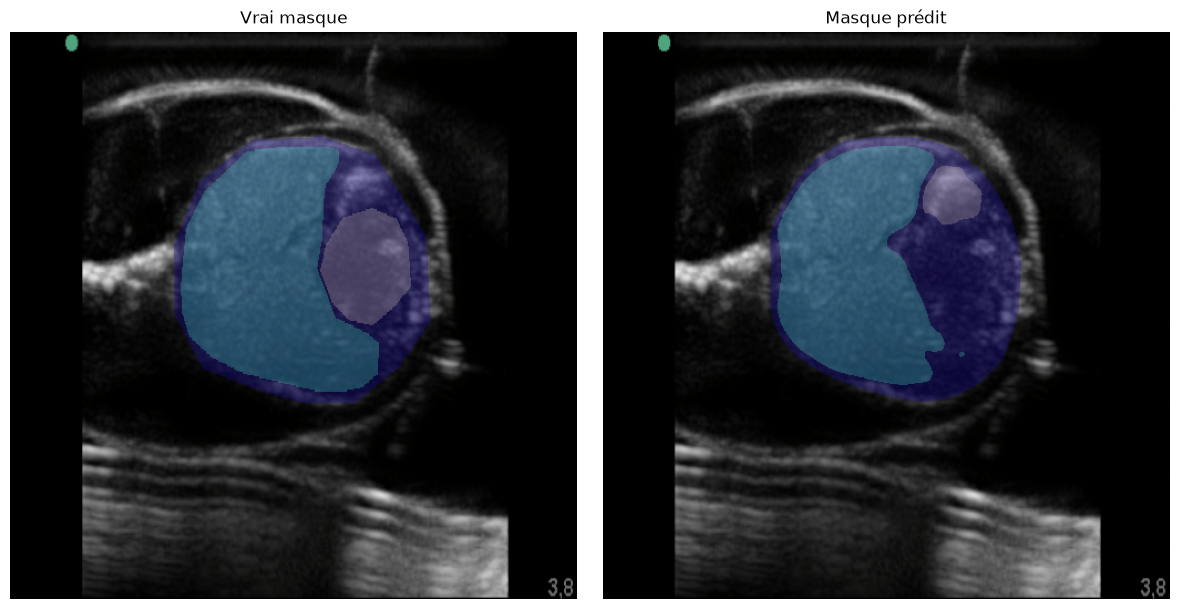

In [9]:
threshold = 0.5
idx = 0  # index de la coupe à afficher dans le batch

# -------- 1. Récupérer une image d'un batch --------
data_iterator = iter(test_loader)
sample_batch1 = next(data_iterator)
sample_batch = next(data_iterator)

if IS_SEQUENCE:
    sample_images_disp = sample_batch['image'].squeeze(0)              # (T, C, H, W) - pour affichage
    sample_input = sample_batch['image'].to(device)                    # (1, T, C, H, W) - séquence complète, entrée modèle
    true_mask = sample_batch['mask'].squeeze(0)[idx]                    # (num_classes, H, W)
    n_slices = sample_images_disp.size(0)
else:
    sample_images_disp = sample_batch['image']                        # (B, C, H, W)
    sample_input = sample_batch['image'][idx].unsqueeze(0).to(device)  # (1, C, H, W)
    true_mask = sample_batch['mask'][idx]
    n_slices = 1

# -------- 2. Récupérer les prédictions de l'image --------
with torch.no_grad():
    ensemble_probs_full = torch.zeros((n_slices, num_classes, IMAGE_SIZE[0], IMAGE_SIZE[1])).to(device)
    for m in models_ensemble:
            outputs = m(sample_input)
            if IS_SEQUENCE:
                outputs = outputs.squeeze(0)  # (1, T, num_classes, H, W) -> (T, num_classes, H, W)
            ensemble_probs_full += torch.sigmoid(outputs)
    # Faire la moyenne sur les folds
    ensemble_probs_full = ensemble_probs_full / len(models_ensemble)

    ensemble_probs = ensemble_probs_full[idx if IS_SEQUENCE else 0].unsqueeze(0)
    pred_mask = (ensemble_probs[0] > threshold).float().cpu()

# -------- 3. Affichage de l'image et des masques --------
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Vrai Masque
true_display = overlay_mask(sample_images_disp[idx], true_mask, alpha=0.3)
axes[0].imshow(true_display)
axes[0].set_title("Vrai masque")
axes[0].axis('off')

# Masque Prédit
pred_display = overlay_mask(sample_images_disp[idx], pred_mask, alpha=0.3)
axes[1].imshow(pred_display)
axes[1].set_title("Masque prédit")
axes[1].axis('off')

plt.tight_layout()
plt.show()

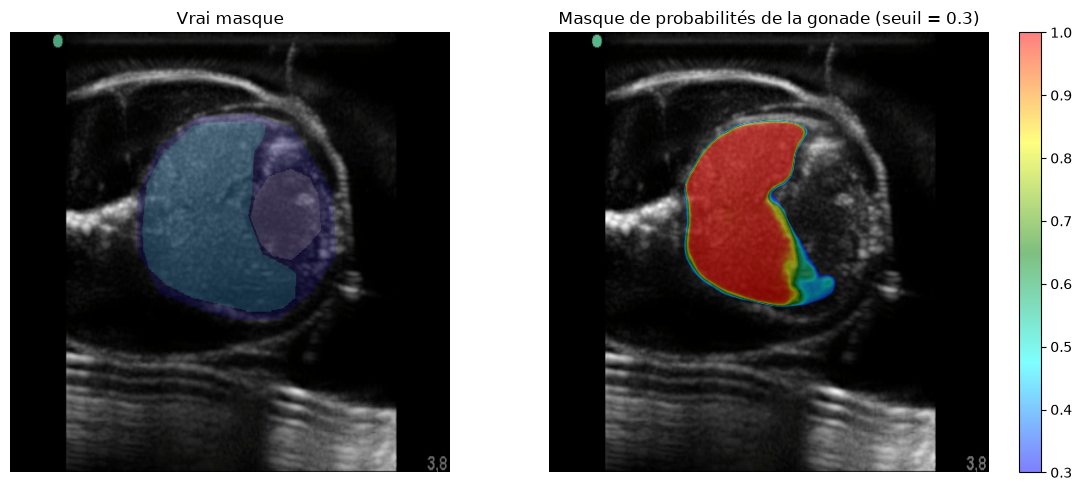

In [10]:
# -------- Paramètres --------
threshold = 0.3  # Seuil pour ignorer les pixels < 0.3
classe_cible = 1  # Classe à visualiser

# -------- Récupérer les probabilités --------
probs_classe_1 = ensemble_probs[0, classe_cible].cpu().numpy()  # Shape: (H, W)

# -------- Créer la colormap (bleu -> rouge) --------
colors = ["blue", "cyan", "green", "yellow", "red"]
cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=256)

# -------- Masquer les pixels sous le seuil --------
# Les pixels < threshold seront totalement ignorés par Matplotlib
probs_masked = np.ma.masked_where(probs_classe_1 < threshold, probs_classe_1)

# -------- Image originale (normalisée) --------
sample_image_np = sample_images_disp[idx].cpu().numpy()
if sample_image_np.shape[0] == 3:  # Format (C, H, W) -> (H, W, C)
    sample_image_np = np.transpose(sample_image_np, (1, 2, 0))
sample_image_np = (sample_image_np - sample_image_np.min()) / (sample_image_np.max() - sample_image_np.min())

# -------- Affichage --------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Vrai Masque
true_display = overlay_mask(sample_images_disp[idx], true_mask, alpha=0.2)
axes[0].imshow(true_display)
axes[0].set_title("Vrai masque")
axes[0].axis('off')

# 1. Afficher d'abord l'image d'origine en fond
axes[1].imshow(sample_image_np)

# 2. Superposer la carte de probabilité masquée avec de la transparence (alpha)
im = axes[1].imshow(probs_masked, cmap=cmap, vmin=threshold, vmax=1, alpha=0.5)

# 3. Lier la colorbar à l'objet 'im'
cbar = plt.colorbar(
    im,
    ax=axes[1],
    ticks=np.arange(threshold, 1.1, 0.1),
)

axes[1].set_title(f"Masque de probabilités de la gonade (seuil = {threshold})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Résultats, métriques et sauvegarde

In [11]:
# --- Affichage performances finales ---
if count > 0:
    # Calculs globaux sur tout le dataset
    mean_iou_per_class = total_iou_per_class / count
    
    precision_per_class = total_tp_per_class / (total_tp_per_class + total_fp_per_class + 1e-6)
    recall_per_class = total_tp_per_class / (total_tp_per_class + total_fn_per_class + 1e-6)
    f1_per_class = 2 * total_tp_per_class / (2 * total_tp_per_class + total_fp_per_class + total_fn_per_class + 1e-6)

    mean_diff_surface_per_class = total_diff_surface_per_class / count
    mean_ratio_surface_per_class = total_ratio_surface_per_class / count
    
    print("\n" + "="*60)
    print("--- PERFORMANCES PAR CLASSE SUR LE DATASET DE TEST ---")
    print("="*60)
    
    for idx, cat_id in enumerate(class_ids):
        # Si categories est un dict, ajustez selon votre implémentation.
        class_name = categories[cat_id] 
        print(f"Classe : {class_name.upper()}")
        print(f"  -> IoU (Moyenne) : {mean_iou_per_class[idx]:.4f}")
        print(f"  -> Précision     : {precision_per_class[idx]:.4f}")
        print(f"  -> Rappel        : {recall_per_class[idx]:.4f}")
        print(f"  -> F1-Score      : {f1_per_class[idx]:.4f}")
        print(f"  -> Différence surfaces (moyenne) : {mean_diff_surface_per_class[idx]:.2f} pixels")
        print(f"  -> Ratio surfaces (moyenne)     : {mean_ratio_surface_per_class[idx]:.4f}")
        print(f"  -> [Pixels] TP: {int(total_tp_per_class[idx])} | FP: {int(total_fp_per_class[idx])} | FN: {int(total_fn_per_class[idx])}")
        print("-" * 60)
        
    print(f"\n=> Mean IoU globale (mIoU)  : {mean_iou_per_class.mean():.4f}")
    print(f"=> F1-Score global (mF1)    : {f1_per_class.mean():.4f}")
else:
    print("Aucune image testée.")


--- PERFORMANCES PAR CLASSE SUR LE DATASET DE TEST ---
Classe : CAVITE
  -> IoU (Moyenne) : 0.9250
  -> Précision     : 0.9535
  -> Rappel        : 0.9721
  -> F1-Score      : 0.9627
  -> Différence surfaces (moyenne) : 1145.07 pixels
  -> Ratio surfaces (moyenne)     : 0.0390
  -> [Pixels] TP: 431332 | FP: 21015 | FN: 12389
------------------------------------------------------------
Classe : GONADE
  -> IoU (Moyenne) : 0.7847
  -> Précision     : 0.8371
  -> Rappel        : 0.9221
  -> F1-Score      : 0.8776
  -> Différence surfaces (moyenne) : 2539.27 pixels
  -> Ratio surfaces (moyenne)     : 0.1914
  -> [Pixels] TP: 196668 | FP: 38269 | FN: 16610
------------------------------------------------------------
Classe : INTESTIN
  -> IoU (Moyenne) : 0.3970
  -> Précision     : 0.7009
  -> Rappel        : 0.5216
  -> F1-Score      : 0.5981
  -> Différence surfaces (moyenne) : 1011.33 pixels
  -> Ratio surfaces (moyenne)     : 28333333.5838
  -> [Pixels] TP: 21345 | FP: 9108 | FN: 19574

### Résultats par images du jeu de test

In [14]:
[x["image_info"]["file_name"] for x in test_samples]

['0004572_10.29.35_356302_2019.jpg',
 '0004573_10.30.05_356302_2019.jpg',
 '0004574_10.30.33_356302_2019.jpg',
 '0004672_12.18.23_356948_2019.jpg',
 '0004673_12.18.32_356948_2019.jpg',
 '0004674_12.18.40_356948_2019.jpg',
 '0004675_12.18.49_356948_2019.jpg',
 '0006926_09.44.56_426687_2024.jpg',
 '0006928_09.45.51_426687_2024.jpg',
 '0006929_09.46.01_426687_2024.jpg',
 '0007138_10.27.57_427242_2024.jpg',
 '0007140_10.43.46_427266_2024.jpg',
 '0007141_10.43.56_427266_2024.jpg',
 '0007142_10.44.03_427266_2024.jpg',
 '0007143_10.44.12_427266_2024.jpg']

In [15]:
iou_gonade = []
ratio_gonade = []
f1_list_gonade = []
diff_surface_gonade = []
for i in range(len(iou_list)):
    iou_gonade.append(f"{iou_list[i][1]:.3f}")
    ratio_gonade.append(f"{ratio_surface_list[i][1]:.3f}")
    f1_list_gonade.append(f"{f1_list[i][1]:.3f}")
    diff_surface_gonade.append(f"{diff_surface_list[i][1] * echelle_cm_par_pixel[i]**2:.3f}")

print("------- IOU GONADE -------")
print(iou_gonade)
print(f"Min : {min(iou_gonade)}")
print(f"Max : {max(iou_gonade)}")

print("------- DIFF SURFACES GONADE EN CM2-------")
print(diff_surface_gonade)
print(f"Min : {min(diff_surface_gonade)}")
print(f"Max : {max(diff_surface_gonade)}")

print("------- RATIO DIFF SURFACES GONADE -------")
print(ratio_gonade)
print(f"Min : {min(ratio_gonade)}")
print(f"Max : {max(ratio_gonade)}")

print("------- F1 SCORE GONADE -------")
print(f1_list_gonade)
print(f"Min : {min(f1_list_gonade)}")
print(f"Max : {max(f1_list_gonade)}")


------- IOU GONADE -------
['0.601', '0.600', '0.747', '0.843', '0.874', '0.822', '0.826', '0.861', '0.765', '0.891', '0.877', '0.613', '0.813', '0.871', '0.767']
Min : 0.600
Max : 0.891
------- DIFF SURFACES GONADE EN CM2-------
['0.315', '0.327', '0.081', '0.045', '0.162', '0.113', '0.074', '0.038', '0.114', '0.052', '0.094', '0.016', '0.192', '0.049', '0.064']
Min : 0.016
Max : 0.327
------- RATIO DIFF SURFACES GONADE -------
['0.643', '0.650', '0.262', '0.057', '0.110', '0.123', '0.127', '0.045', '0.147', '0.096', '0.103', '0.027', '0.142', '0.061', '0.278']
Min : 0.027
Max : 0.650
------- F1 SCORE GONADE -------
['0.750', '0.750', '0.855', '0.915', '0.933', '0.902', '0.904', '0.925', '0.867', '0.942', '0.935', '0.760', '0.897', '0.931', '0.868']
Min : 0.750
Max : 0.942


### Sauvegarder les résultats

In [14]:
iou_categories = {'all_iou': iou_gonade, 
               'categories': test_categories}

# Sauvegarde des valeurs d'IoU sur le test
with open("saves/categories_test_xlstm.pkl", 'wb') as f:
    pickle.dump(iou_categories, f)